# Multiple Linear Regression

## Objectives

After completing this lab, you should be able to:

- Explain the difference between simple and multiple linear regression
- Use scikit-learn to create, train, and test a multiple linear regression model
- Interpret coefficients as **partial effects**, with the other input features held constant
- Avoid data leakage by fitting preprocessing steps on the training data only
- Evaluate a regression model with test metrics instead of relying only on plots
- Recognize when a linear model is too simple for the structure in the data

## The central idea

Simple linear regression predicts a target from one input feature:

$$\hat{y} = b_0 + b_1x_1$$

Multiple linear regression uses two or more input features:

$$\hat{y} = b_0 + b_1x_1 + b_2x_2 + \cdots + b_px_p$$

In this lab, the target is a vehicle's CO₂ emissions and the two selected inputs are engine size and combined fuel economy in MPG:

$$\widehat{CO2} = b_0 + b_1(\text{engine size}) + b_2(\text{MPG})$$

With one feature, the fitted model is a line. With two features, it is a plane. With more features, it is called a hyperplane.

> **Key interpretation:** each coefficient describes the association between one feature and the prediction **while the other model features are held constant**. This is what makes multiple regression different from fitting unrelated simple regression lines.


## Install needed packages

This lab requires NumPy, Matplotlib, pandas, and scikit-learn. If they are not already available in your environment, install them from a terminal with:

```bash
uv pip install numpy matplotlib pandas scikit-learn
```

## Import the libraries

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

### Load the data

In [32]:
df = pd.read_csv('fuel_consumption_co2.csv')

In [33]:
# Verify successful dataset load with some randomly selected records
df.sample(5)

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
313,2014,DODGE,CHARGER SRT (MDS),FULL-SIZE,6.4,8,A5,Z,16.7,10.3,13.8,20,317
754,2014,MERCEDES-BENZ,G 550,SUV - STANDARD,5.5,8,AS7,Z,20.0,15.9,18.2,16,419
198,2014,CHEVROLET,CRUZE,MID-SIZE,1.4,4,M6,X,9.1,6.3,7.8,36,179
741,2014,MERCEDES-BENZ,E 350 4MATIC,MID-SIZE,3.5,6,AS7,Z,11.6,8.1,10.0,28,230
560,2014,JAGUAR,XJL SUPERCHARGED,FULL-SIZE,5.0,8,AS8,E,20.6,13.6,17.5,16,280


### Explore and select features

Feature selection is not simply "keep every column that correlates with the target." We also ask:

1. Is the feature available when a future prediction is made?
2. Is its relationship with the target reasonably represented by a straight line?
3. Does it duplicate information already supplied by another feature?
4. Is it numeric, or does it require categorical encoding first?

For this introductory lab, we will use a small set of numeric features. In a real project, categorical columns such as fuel type, vehicle class, and transmission could contain useful information and should be investigated rather than automatically discarded.


In [34]:
df.describe()

,MODELYEAR,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
count,1067.0,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000
mean,2014.0,3.346298,5.794752,13.296532,9.474602,11.580881,26.441425,256.228679
std,0.0,1.415895,1.797447,4.101253,2.794510,3.485595,7.468702,63.372304
min,2014.0,1.000000,3.000000,4.600000,4.900000,4.700000,11.000000,108.000000
25%,2014.0,2.000000,4.000000,10.250000,7.500000,9.000000,21.000000,207.000000
50%,2014.0,3.400000,6.000000,12.600000,8.800000,10.900000,26.000000,251.000000
75%,2014.0,4.300000,8.000000,15.550000,10.850000,13.350000,31.000000,294.000000
max,2014.0,8.400000,12.000000,30.200000,20.500000,25.800000,60.000000,488.000000


Notice that some variables are absent from `describe()` because they are categorical rather than numeric. They are omitted here to keep the exercise focused, not because categorical variables are inherently unusable. They could be encoded in a more complete model.

`MODELYEAR` is constant for every row, so it cannot explain differences between vehicles and can safely be removed.


In [35]:
# Drop categoricals and any useless columns
df = df.drop(['MODELYEAR', 'MAKE', 'MODEL', 'VEHICLECLASS', 'TRANSMISSION', 'FUELTYPE',], axis=1)

Now examine the correlations among the remaining numeric variables.

A correlation matrix measures the strength of **pairwise linear relationships**. The bottom row shows how each feature correlates with `CO2EMISSIONS`, while the other cells help identify features that carry nearly duplicate information.

Highly correlated input features can make individual coefficients unstable or difficult to interpret. This is called **multicollinearity**. It does not automatically make predictions unusable, but it can make it hard to separate each feature's individual contribution.

> Correlation is only a screening tool. A high correlation does not prove causation, and a low correlation does not rule out a useful nonlinear relationship.


In [36]:
df.corr()

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
ENGINESIZE,1.000000,0.934011,0.832225,0.778746,0.819482,-0.808554,0.874154
CYLINDERS,0.934011,1.000000,0.796473,0.724594,0.776788,-0.770430,0.849685
FUELCONSUMPTION_CITY,0.832225,0.796473,1.000000,0.965718,0.995542,-0.935613,0.898039
FUELCONSUMPTION_HWY,0.778746,0.724594,0.965718,1.000000,0.985804,-0.893809,0.861748
FUELCONSUMPTION_COMB,0.819482,0.776788,0.995542,0.985804,1.000000,-0.927965,0.892129
FUELCONSUMPTION_COMB_MPG,-0.808554,-0.770430,-0.935613,-0.893809,-0.927965,1.000000,-0.906394
CO2EMISSIONS,0.874154,0.849685,0.898039,0.861748,0.892129,-0.906394,1.000000


The bottom row shows that the numeric candidates are strongly correlated with `CO2EMISSIONS`.

`ENGINESIZE` and `CYLINDERS` are also strongly correlated with each other. To avoid giving the model two very similar engine descriptors, we keep `ENGINESIZE`, which has the stronger relationship with the target in this dataset.

The four fuel-economy variables represent closely related measurements. We keep `FUELCONSUMPTION_COMB_MPG` and remove the others for this illustration.

Notice that `FUELCONSUMPTION_COMB` and `FUELCONSUMPTION_COMB_MPG` are not perfectly correlated even though they describe related fuel-economy concepts in different units. In a real analysis, that discrepancy deserves investigation rather than being ignored.

This is a deliberately simplified feature-selection decision, not a universal recipe.


In [37]:
df = df.drop(['CYLINDERS', 'FUELCONSUMPTION_CITY', 'FUELCONSUMPTION_HWY','FUELCONSUMPTION_COMB',], axis=1)

In [38]:
df.head(9)

,ENGINESIZE,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2.0,33,196
1,2.4,29,221
2,1.5,48,136
3,3.5,25,255
4,3.5,27,244
5,3.5,28,230
6,3.5,28,232
7,3.7,25,255
8,3.7,24,267


To help with selecting predictive features that are not redundant, consider the following scatter matrix, which shows the scatter plots for each pair of input features. The diagonal of the matrix shows each feature's histogram.

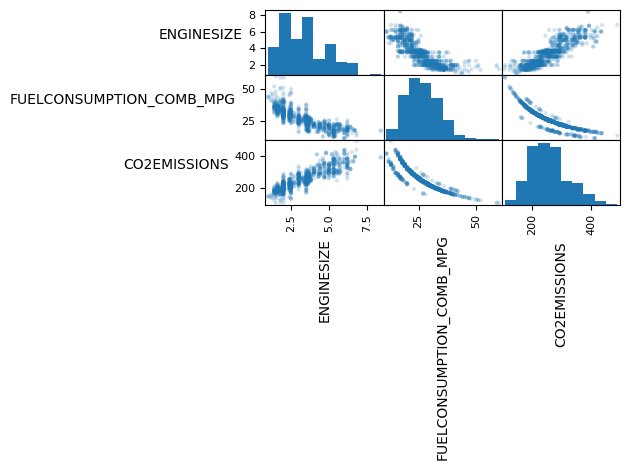

In [39]:
axes = pd.plotting.scatter_matrix(df, alpha=0.2)
# We need to rotate axis label so we can read them
for ax in axes.flatten():
    ax.xaxis.label.set_rotation(90)
    ax.yaxis.label.set_rotation(0)
    ax.yaxis.label.set_ha('right')

plt.tight_layout()
plt.gcf().subplots_adjust(wspace=0, hspace=0)
plt.show()

The relationship between `FUELCONSUMPTION_COMB_MPG` and `CO2EMISSIONS` is visibly nonlinear, and the points appear to form several curves or groups.

That observation is a warning: multiple linear regression can only fit a plane, so it may underfit this structure. The groups may be related to categorical variables that were removed, such as fuel type or vehicle class. A later model could add encoded categorical features, transformed terms, or a nonlinear estimator.

For now, we keep MPG intentionally. The goal is to practice multiple regression and then diagnose where its assumptions do not match the data.


### Extract the input features and target

Use column names rather than numeric positions. Named columns make the model definition explicit and prevent accidental breakage if the dataframe's column order changes.

`X` is a two-dimensional feature matrix with one column per predictor. `y` is the target column containing the observed CO2 emissions.


In [40]:
feature_names = ['ENGINESIZE', 'FUELCONSUMPTION_COMB_MPG']
target_name = 'CO2EMISSIONS'

X = df[feature_names].to_numpy()
y = df[[target_name]].to_numpy()

print('X shape:', X.shape)
print('y shape:', y.shape)


X shape: (1067, 2)


y shape: (1067, 1)


### Create, train, and test datasets **before preprocessing**

Reserve 20% of the observations for final testing. The test set represents future, unseen data and must not influence anything learned during training.

This includes preprocessing parameters. Therefore, splitting must happen before fitting the scaler.


In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)


### Standardize without leaking test information

Standardization subtracts a feature's mean and divides by its standard deviation:

$$z = \frac{x - \mu}{\sigma}$$

The crucial workflow is:

- `fit_transform(X_train)`: learn the means and standard deviations from training data, then transform it.
- `transform(X_test)`: reuse those training statistics on the test data.
- Do **not** fit the scaler on all of `X` or separately on `X_test`.

If the scaler sees the full dataset before the split, information about the test distribution leaks into model development. The effect may be small in this lab, but the practice becomes important with cross-validation, regularization, PCA, imputation, and feature selection.

Ordinary unregularized linear regression does not require standardized inputs to make predictions. We use scaling here to make coefficient magnitudes comparable and to practice a workflow that many other estimators require.


In [42]:
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()
X_train_std = std_scaler.fit_transform(X_train)
X_test_std = std_scaler.transform(X_test)

pd.DataFrame(X_train_std, columns=feature_names).describe().round(2)


,ENGINESIZE,FUELCONSUMPTION_COMB_MPG
count,853.00,853.00
mean,-0.00,0.00
std,1.00,1.00
min,-1.67,-2.10
25%,-0.96,-0.73
50%,0.03,-0.04
75%,0.74,0.64
max,3.57,4.48


The standardized **training** features have means near zero and standard deviations near one. The test features are not guaranteed to have exactly zero mean or unit variance, and that is expected: they were transformed with statistics learned from the training set.

In production code, a scikit-learn `Pipeline` is often preferred because it keeps preprocessing and modeling together and reduces the chance of leakage. The explicit steps above are shown first so that the data flow is easy to see.


### Build a multiple linear regression model

Scikit-learn uses the same `LinearRegression` class for simple and multiple regression. The number of columns in `X` determines how many input features the model uses.

The model chooses the coefficients that minimize the sum of squared residuals on the training data. A residual is the vertical difference between an observed target and its prediction:

$$e_i = y_i - \hat{y}_i$$


In [43]:
from sklearn.linear_model import LinearRegression

regressor = LinearRegression()
regressor.fit(X_train_std, y_train)

coef_ = regressor.coef_
intercept_ = regressor.intercept_

print('Standardized-space coefficients:', coef_)
print('Standardized-space intercept:', intercept_)


Standardized-space coefficients: [[ 25.24920416 -36.60577657]]


Standardized-space intercept: [257.25674091]


The coefficients and intercept define the best-fit plane.

Because the model was trained on standardized features, these coefficients describe changes measured in standard deviations. A positive coefficient raises the prediction as that feature increases; a negative coefficient lowers it, **with the other feature held constant**.

This conditional interpretation matters. It is not the same as looking at the raw relationship between one feature and CO₂ while ignoring the other feature.

To express the model in liters and MPG, transform the parameters back to the original feature space.


In [44]:
# Get the standard scaler's mean and standard deviation parameters
means_ = std_scaler.mean_
std_devs_ = np.sqrt(std_scaler.var_)

# The least square params can be calculated relative to the og, unstandardized feature space as:
coef_original = coef_ / std_devs_
intercept_original = intercept_ - np.sum((means_ * coef_) / std_devs_)

print('Coefficients: ', coef_original)
print('Intercept: ', intercept_original)

Coefficients:  [[17.8581369  -5.01502179]]


Intercept:  [329.1363967]


The original-space model can be read approximately as:

$$\widehat{CO2} = b_0 + b_1(\text{engine size}) + b_2(\text{MPG})$$

- $b_1$: expected change in predicted CO2 for one additional liter of engine size, with MPG held constant.
- $b_2$: expected change in predicted CO2 for one additional MPG, with engine size held constant.

Do not over-interpret the intercept as a physical statement about a vehicle with zero engine size and zero MPG. Those values are outside the realistic data range, so the intercept mainly positions the fitted plane mathematically. A nonzero intercept by itself does **not** prove that the model is poor.

Model quality should instead be judged from held-out predictions, residuals, and evaluation metrics. Nonlinearity, omitted variables, outliers, and multicollinearity are possible concerns, but each requires evidence rather than being inferred from the intercept alone.


### Visualize model outputs

With two input features, the fitted model is a plane in three dimensions. The points' vertical distances from that plane are residuals.

The visualization is useful for intuition, but it should not replace numerical evaluation. Three-dimensional plots can also be difficult to interpret accurately.


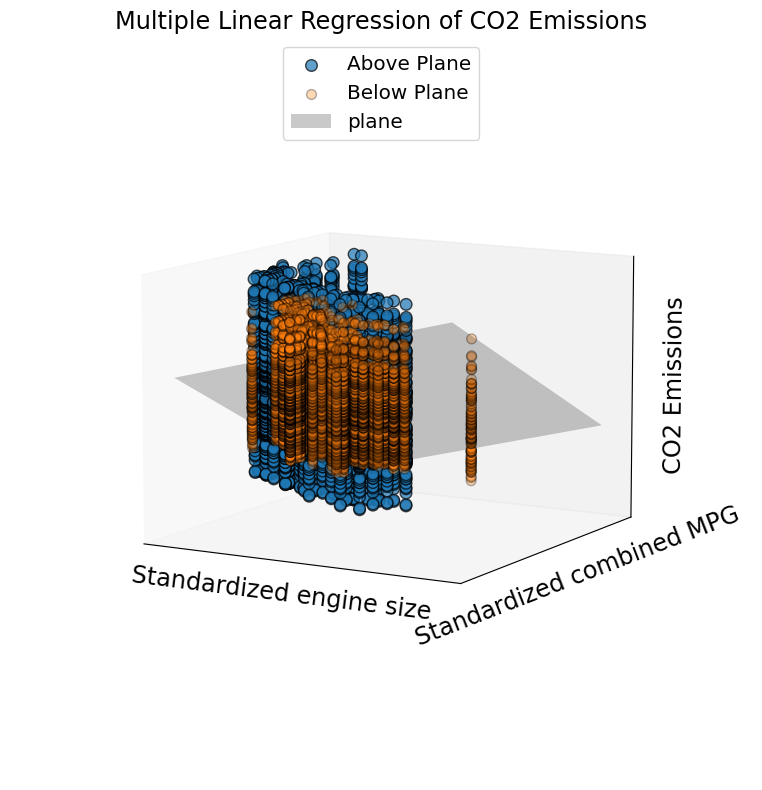

In [45]:
#from mpl_toolkits.mplot3d import Axes3D

# Ensure X1, X2, and y_test have compatible shapes for 3D plotting
X1 = X_test_std[:, 0]
X2 = X_test_std[:, 1]

# Create a mesh grid for plotting the regression plane
x1_surf, x2_surf = np.meshgrid(np.linspace(X1.min(), X1.max(), 100),
                               np.linspace(X2.min(), X2.max(), 100))

y_surf = intercept_ + coef_[0, 0] * x1_surf + coef_[0, 1] * x2_surf

# Predict y values using trained regression model to compare with actual y_test for above/below plane colors
y_pred = regressor.predict(X_test_std.reshape(-1, 1)) if X_test_std.ndim == 1 else regressor.predict(X_test_std)
above_plane = y_test >= y_pred
below_plane = y_test < y_pred
above_plane = above_plane[:, 0]
below_plane = below_plane[:, 0]

# Plotting
fig = plt.figure(figsize=(20, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the data points above and below the plane in different colors
ax.scatter(X1[above_plane], X2[above_plane], y_test[above_plane], label='Above Plane', s=70, alpha=0.7, ec='k')
ax.scatter(X1[below_plane], X2[below_plane], y_test[below_plane], label='Below Plane', s=50, alpha=0.3, ec='k')

# Plot the regression plane
ax.plot_surface(x1_surf, x2_surf, y_surf, color='k', alpha=0.21, label='plane')

# Set view and labels
ax.view_init(elev=10)

ax.legend(fontsize='x-large', loc='upper center')

ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])

ax.set_box_aspect(None, zoom=0.75)

ax.set_xlabel('Standardized engine size', fontsize='xx-large')
ax.set_ylabel('Standardized combined MPG', fontsize='xx-large')
ax.set_zlabel('CO2 Emissions', fontsize='xx-large')

ax.set_title('Multiple Linear Regression of CO2 Emissions', fontsize='xx-large')

plt.tight_layout()
plt.show()

Instead of relying only on a 3D plot, the next cells show each feature against CO2.

Be careful: these are **not true slices of the fitted plane** because the other feature is not fixed to one constant value for all points. The red line shows the selected coefficient plus the intercept, but each blue observation has its own value for the other predictor.

For a proper partial-effect plot, choose a fixed value for the other feature, such as its training mean, and vary only the feature being displayed.


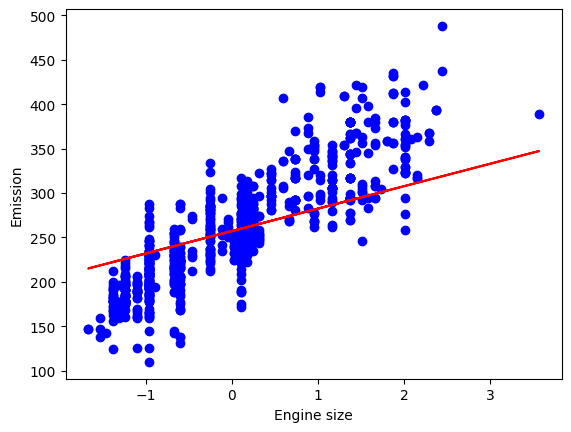

In [46]:
plt.scatter(X_train_std[:,0], y_train,  color='blue')
plt.plot(X_train_std[:,0], coef_[0,0] * X_train_std[:,0] + intercept_[0], '-r')
plt.xlabel("Engine size")
plt.ylabel("Emission")
plt.show()

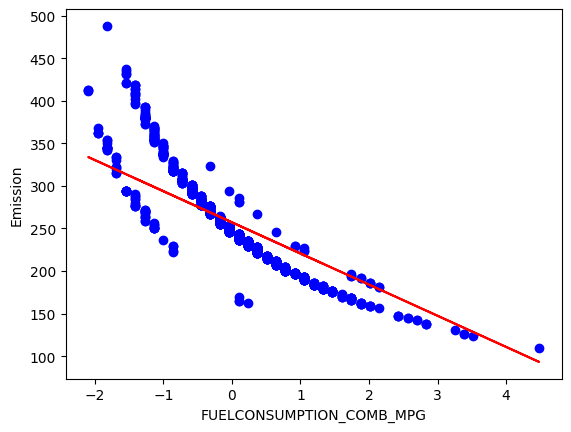

In [47]:
plt.scatter(X_train_std[:,1], y_train,  color='blue')
plt.plot(X_train_std[:,1], coef_[0,1] * X_train_std[:,1] + intercept_[0], '-r')
plt.xlabel("FUELCONSUMPTION_COMB_MPG")
plt.ylabel("Emission")
plt.show()

The plots suggest that a plane may be too simple for the data, especially because the MPG relationship is curved and appears to contain groups. However, visual inspection alone is not enough to call the model "poor." We should evaluate predictions on the held-out test set.


In [48]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = regressor.predict(X_test_std)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f'MAE:  {mae:.2f} g/km')
print(f'RMSE: {rmse:.2f} g/km')
print(f'R^2:  {r2:.3f}')


MAE:  14.29 g/km


RMSE: 21.59 g/km


R^2:  0.887


### How to read these metrics

- **MAE** is the average absolute prediction error in g/km. It is usually the easiest metric to explain.
- **RMSE** is also measured in g/km, but it penalizes large errors more heavily.
- **R-squared** is the fraction of target variance explained relative to predicting the test-set mean. Values closer to 1 are better, while values at or below 0 indicate that the model is no better than, or worse than, that baseline.

Metrics tell us how well the model predicts; residual plots help tell us **why** it makes mistakes. Curved residual patterns would support the concern that a linear plane is underfitting the data.


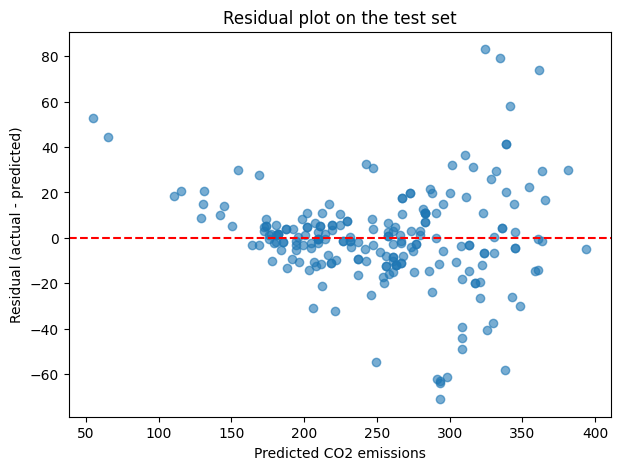

In [49]:
residuals = y_test - y_pred

plt.figure(figsize=(7, 5))
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted CO2 emissions')
plt.ylabel('Residual (actual - predicted)')
plt.title('Residual plot on the test set')
plt.show()


### The same workflow with a Pipeline

The explicit scaling steps above are useful while learning because you can see exactly where `fit` and `transform` happen. In normal project code, a `Pipeline` is often safer: calling `fit` learns both the scaler and regression parameters from the training data, while `predict` automatically applies the already-fitted scaler to new data.


In [50]:
from sklearn.pipeline import Pipeline

pipeline_model = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', LinearRegression()),
])

pipeline_model.fit(X_train, y_train)
pipeline_predictions = pipeline_model.predict(X_test)

print('Pipeline produces the same predictions:',
      np.allclose(y_pred, pipeline_predictions))


Pipeline produces the same predictions: True


## Practice: compare multiple and simple regression

The exercises below fit one-feature models. Their purpose is not to prove that simple regression is always better. They let you compare models and ask whether adding MPG contributes useful linear information beyond engine size.

Use the already standardized training and test arrays so that the comparison uses the same split and preprocessing.


### Exercise 1

Determine and print the parameters for the best-fit linear regression line for CO2 emission with respect to engine size.

In [51]:
X_train_1 = X_train_std[:, [0]]

regressor_1 = LinearRegression()
regressor_1.fit(X_train_1, y_train)

coef_1 = regressor_1.coef_[0, 0]
intercept_1 = regressor_1.intercept_[0]

print('Coefficient:', coef_1)
print('Intercept:', intercept_1)

Coefficient: 55.13126515289232


Intercept: 257.25674091441977


### Exercise 2

Produce a scatterplot of CO2 emission against ENGINESIZE and include the best-fit regression line to the training data.

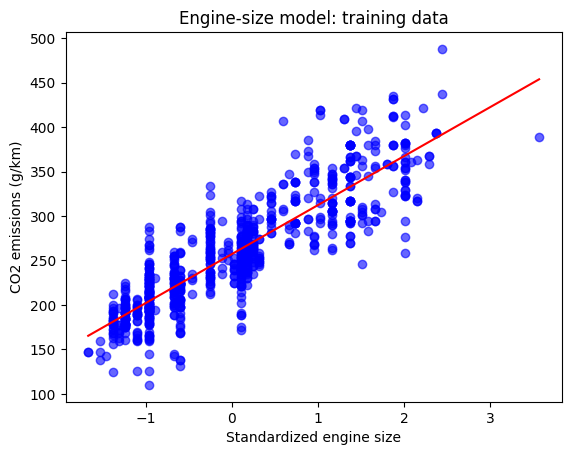

In [52]:
train_order_1 = np.argsort(X_train_1[:, 0])

plt.scatter(X_train_1[:, 0], y_train[:, 0], color='blue', alpha=0.6)
plt.plot(
    X_train_1[train_order_1, 0],
    regressor_1.predict(X_train_1[train_order_1])[:, 0],
    color='red',
)
plt.xlabel('Standardized engine size')
plt.ylabel('CO2 emissions (g/km)')
plt.title('Engine-size model: training data')
plt.show()

The engine-size line may look cleaner than the earlier two-dimensional projections. That visual impression does not establish that the simple model predicts better than the multiple model. Compare both models on the **same test rows** with MAE, RMSE, and R-squared.

Adding a feature cannot increase ordinary least-squares training error, but it may fail to improve test performance if the feature adds noise, redundancy, or a relationship that is not well represented linearly.


### Exercise 3

Generate the same scatterplot and best-fit regression line, but now base the result on the test data set. Consider how the test result compares to the training result.

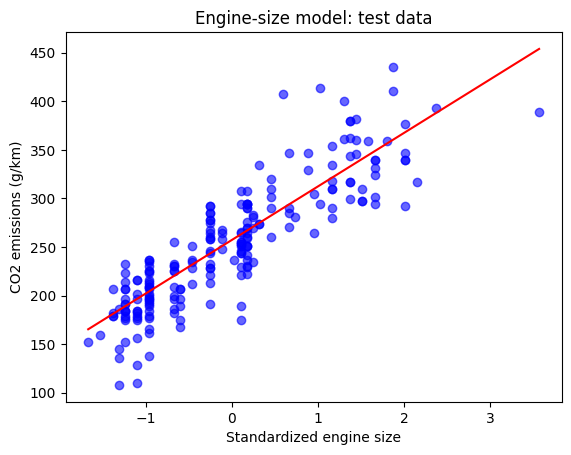

In [53]:
X_test_1 = X_test_std[:, [0]]
test_order_1 = np.argsort(X_test_1[:, 0])

plt.scatter(X_test_1[:, 0], y_test[:, 0], color='blue', alpha=0.6)
plt.plot(
    X_test_1[test_order_1, 0],
    regressor_1.predict(X_test_1[test_order_1])[:, 0],
    color='red',
)
plt.xlabel('Standardized engine size')
plt.ylabel('CO2 emissions (g/km)')
plt.title('Engine-size model: test data')
plt.show()

### Exercise 4

Repeat the same modeling but use FUELCONSUMPTION_COMB_MPG as the independent variable instead. Display the model coefficients including the intercept.

In [54]:
X_train_2 = X_train_std[:, [1]]

regressor_2 = LinearRegression()
regressor_2.fit(X_train_2, y_train)

coef_2 = regressor_2.coef_[0, 0]
intercept_2 = regressor_2.intercept_[0]

print('Coefficient:', coef_2)
print('Intercept:', intercept_2)

Coefficient: -57.21722999405407


Intercept: 257.2567409144197


### Exercise 5

Generate a scatter plot showing the results as before on the test data. Consider well the model fits, and what you might be able to do to improve it. We'll revisit this later in the course.

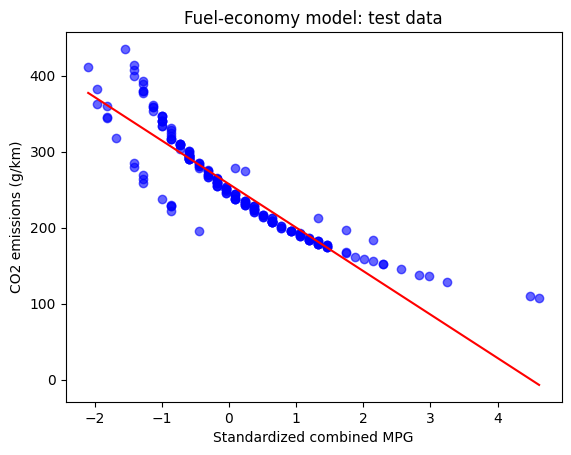

In [55]:
X_test_2 = X_test_std[:, [1]]
test_order_2 = np.argsort(X_test_2[:, 0])

plt.scatter(X_test_2[:, 0], y_test[:, 0], color='blue', alpha=0.6)
plt.plot(
    X_test_2[test_order_2, 0],
    regressor_2.predict(X_test_2[test_order_2])[:, 0],
    color='red',
)
plt.xlabel('Standardized combined MPG')
plt.ylabel('CO2 emissions (g/km)')
plt.title('Fuel-economy model: test data')
plt.show()

## Takeaways

1. Multiple linear regression predicts one target from several features by fitting a plane or hyperplane.
2. Each coefficient is a partial effect: interpret it while holding the other included features constant.
3. Split the data before fitting preprocessing. Fit the scaler on `X_train` and only transform `X_test`.
4. Standardization is useful for coefficient comparison and is essential for many estimators, though plain unregularized linear regression does not require it for prediction.
5. Correlation can reveal redundancy, but it does not prove causation or guarantee a good linear model.
6. A nonzero intercept is not automatically a problem, especially when zero lies outside the observed feature range.
7. Judge model quality with held-out metrics and residual analysis, not only with a visually appealing line or plane.
8. More features do not automatically mean a better test model. The feature relationships must match what the estimator can represent.

Possible next improvements include encoding relevant categorical variables, transforming the nonlinear MPG feature, using polynomial terms, and validating alternatives with cross-validation.
